# NEXRAD Gridded and Base Radar Data
**Python-AWIPS Tutorial Notebook**

This notebook shows how to discover radar products and elevation angles, plot
products through the standard gridded Data Access Layer interface, and retrieve
native radial bins with `GetRadarDataRecordRequest`.

## Imports

In [1]:
from datetime import datetime, timedelta

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from metpy.plots import ctables
import numpy as np
from numpy import ma
from pyproj import Geod

from awips import RadarCommon, ThriftClient, tables
from awips.dataaccess import DataAccessLayer
from dynamicserialize.dstypes.com.raytheon.uf.common.dataplugin.radar.request import (
    GetRadarDataRecordRequest,
)
from dynamicserialize.dstypes.com.raytheon.uf.common.time import TimeRange

## Connect to EDEX and select a radar site

In [2]:
edex_host = "edex-cloud.unidata.ucar.edu"
site = "kict"

DataAccessLayer.changeEDEXHost(edex_host)
request = DataAccessLayer.newDataRequest("radar")
request.setLocationNames(site)

available_sites = sorted(DataAccessLayer.getAvailableLocationNames(
    DataAccessLayer.newDataRequest("radar")
))
assert site in available_sites, f"Choose a site from available_sites: {site!r} was not found."
print(f"EDEX reports {len(available_sites)} available radar sites.")
# print(available_sites)

EDEX reports 201 available radar sites.


## Discover and identify radar products

`getAvailableParameters()` returns numeric product codes, mnemonics, and names in
one flat collection. Because multiple codes can share a name, numeric codes are
matched to `tables.nexrad` rather than paired with names by list position.

In [3]:
available_parameters = DataAccessLayer.getAvailableParameters(request)
available_product_ids = sorted(
    DataAccessLayer.getRadarProductIDs(available_parameters), key=int
)

preferred_product_ids = {
    "153", "154", "155", "159", "161", "163", "165",
    "56",  # Useful storm-relative velocity; not a super-resolution product.
}

print(f"Radar products available at {site.upper()}:\n")
print(" * = commonly used high-resolution or storm-relative product\n")
for code in available_product_ids:
    metadata = tables.nexrad.get(code, {})
    marker = "*" if code in preferred_product_ids else " "
    name = metadata.get("name", "Unknown product")
    resolution = metadata.get("res")
    unit = metadata.get("displayUnit", metadata.get("unit", ""))
    resolution_text = f"{resolution:g} km" if resolution is not None else ""
    print(f"{marker} {code:>3}  {name:<43} {resolution_text:>8}  {unit}")

Radar products available at KICT:

 * = commonly used high-resolution or storm-relative product

   32  Digital Hybrid Scan Refl                        1 km  dBZ/10
   37  Composite Refl                                  1 km  dBZ
*  56  Storm Relative Velocity                         1 km  kts
   57  Vert Integ Liq                                  4 km  kg/m²
   58  Storm Track                                     0 km  
   99  Velocity                                     0.25 km  (m/s)/10
  134  Digital Vert Integ Liq                          1 km  kg/m²
  135  Enhanced Echo Tops                              1 km  ft*1000
  141  Mesocyclone                                     0 km  
* 153  Super-Resolution Base Reflectivity           0.25 km  dBZ
* 154  Super-Resolution Base Velocity               0.25 km  kts
* 159  Digital Differential Reflectivity            0.25 km  dB
* 161  Digital Correlation Coefficient              0.25 km  
* 163  Digital Specific Differential Phase          

## Select a product and elevation

All products listed above remain available to the gridded workflow. Product 153
is the default because it is 0.25-km super-resolution base reflectivity.

In [4]:
product_code = "153"
if product_code not in available_product_ids:
    raise ValueError(f"Product {product_code} is not available at {site.upper()}.")

product = tables.nexrad.get(product_code, {
    "id": int(product_code), "name": f"Radar product {product_code}",
    "res": 1.0, "unit": ""
})
request.setParameters(product_code)
available_levels = DataAccessLayer.getAvailableLevels(request)
assert available_levels, "No levels were returned for the selected product."

print("Selected product:", product["name"])
print("Available levels:", available_levels)

Selected product: Super-Resolution Base Reflectivity
Available levels: ['0.5TILT', '0.9TILT', '1.5TILT', '1.8TILT', '2.4TILT', '3.4TILT']


In [5]:
selected_elevation = 0.5
selected_level = next((
    level for level in available_levels
    if np.isclose(float(level.getLevelonevalue()), selected_elevation)
), None)
if selected_level is None:
    raise ValueError(
        f"Elevation {selected_elevation} is unavailable. Choose from {available_levels}."
    )

request.setLevels(selected_level)
elevation = float(selected_level.getLevelonevalue())
available_times = DataAccessLayer.getAvailableTimes(request)
assert available_times, "No times matched the selected site, product, and elevation."
selected_time = available_times[-1]

print("Selected level:", selected_level)
print("Selected time:", selected_time)

Selected level: 0.5TILT
Selected time: 2026-09-03 21:32:45


## Plotting helpers

In [6]:
def make_map(bbox, figsize=(12, 12)):
    fig, ax = plt.subplots(
        figsize=figsize, subplot_kw={"projection": ccrs.PlateCarree()}
    )
    ax.set_extent(bbox, crs=ccrs.PlateCarree())
    ax.coastlines(resolution="50m")
    ax.add_feature(cfeature.STATES, linestyle=":", edgecolor="black", linewidth=0.5)
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = gl.right_labels = False
    return fig, ax


def product_plot_style(metadata):
    if metadata.get("categorical"):
        cmap = plt.get_cmap(metadata.get("cmap", "tab20"))
        return {"cmap": cmap, "norm": BoundaryNorm(np.arange(-0.5, 16.5), cmap.N)}
    if metadata.get("cmap"):
        return {"cmap": plt.get_cmap(metadata["cmap"])}
    if metadata.get("ctable"):
        name, beginning, increment = metadata["ctable"]
        norm, cmap = ctables.registry.get_with_steps(name, beginning, increment)
        return {"cmap": cmap, "norm": norm}
    return {"cmap": plt.get_cmap("turbo")}

# Section 1: Gridded radar data

`getGridData()` is the standard python-awips interface for radar products that
EDEX exposes as grids.

In [ ]:
grid_response = DataAccessLayer.getGridData(request, [selected_time])
assert grid_response, "No gridded radar data matched the request."

grid = grid_response[0]
grid_data = ma.masked_invalid(grid.getRawData())
grid_lons, grid_lats = grid.getLatLonCoords()
grid_bbox = [
    float(np.nanmin(grid_lons)) - 0.25, float(np.nanmax(grid_lons)) + 0.25,
    float(np.nanmin(grid_lats)) - 0.25, float(np.nanmax(grid_lats)) + 0.25,
]

print("Time:", grid.getDataTime())
print("Location:", grid.getLocationName())
print("Parameter:", grid.getParameter())
print("Level:", grid.getLevel())
print("Unit:", grid.getUnit())
print("Shape:", grid_data.shape)

In [ ]:
fig, ax = make_map(grid_bbox)
mesh = ax.pcolormesh(
    grid_lons, grid_lats, grid_data, shading="auto",
    transform=ccrs.PlateCarree(), **product_plot_style(product)
)
cbar = fig.colorbar(mesh, ax=ax, extend="both", shrink=0.75,
                    orientation="horizontal", pad=0.05)
cbar.set_label(
    f"{site.upper()} {product['name']} ({product_code}), "
    f"{grid.getUnit()}, valid {grid.getDataTime()}"
)
ax.set_title(f"Gridded {product['name']} at {selected_level}")
plt.show()

# Section 2: Native base radial data

This request exposes radial bins, azimuth angles, and threshold metadata. The
decoding example is for 256-level radial products. Product 56 can be plotted in
the gridded section, but its 16-level encoding is not decoded here.

In [7]:
if product.get("lvls") != 256:
    raise ValueError("Choose a 256-level product for the native radial section.")

date_time = datetime.strptime(str(selected_time)[:19], "%Y-%m-%d %H:%M:%S")
buffer = timedelta(seconds=60)

radar_request = GetRadarDataRecordRequest()
radar_request.setTimeRange(TimeRange(date_time - buffer, date_time + buffer))
radar_request.setRadarId(site)
radar_request.setProductCode(int(product_code))
radar_request.setPrimaryElevationAngle(elevation)

client = ThriftClient.ThriftClient(edex_host)
radar_response = client.sendRequest(radar_request)
records = radar_response.getData() or []
assert records, "No native radar records matched the request."
print(f"Returned {len(records)} native radar record(s).")

Returned 1 native radar record(s).


In [8]:
record = records[0]
radial_data, angle_data, dependent_values, threshold_values = (
    RadarCommon.get_hdf5_data(record.getHdf5Data())
)
if not radial_data or not angle_data:
    raise ValueError("The selected product did not return radial data and angles.")
if len(threshold_values) < 2:
    raise ValueError("The selected product did not return decoding thresholds.")

radials, range_gates = radial_data.getSizes()
raw = np.asarray(radial_data.getByteData(), dtype=np.int16)
raw[raw < 0] += 256
raw = raw.reshape(radials, range_gates)

minimum = threshold_values[0] / 10.0
increment = threshold_values[1] / 10.0
base_data = ma.masked_where(raw <= 1, minimum + raw * increment)
if product_code in {"154", "155"}:
    base_data *= 1.94384  # meters per second to knots
if product.get("categorical"):
    base_data = ma.round(base_data)

latitude = float(record.getLatitude())
longitude = float(record.getLongitude())
azimuths = np.asarray(angle_data.getFloatData(), dtype=float)
azimuth_edges = np.append(azimuths, azimuths[-1])
range_edges = np.arange(range_gates + 1, dtype=float)
gate_resolution_m = float(product["res"]) * 1000.0

shape = (len(azimuth_edges), len(range_edges))
center_lats = np.full(shape, latitude)
center_lons = np.full(shape, longitude)
azimuth_grid = np.broadcast_to(azimuth_edges[:, None], shape)
range_grid = np.broadcast_to(range_edges[None, :] * gate_resolution_m, shape)

geod = Geod(ellps="clrk66")
base_lons, base_lats, _ = geod.fwd(
    center_lons, center_lats, azimuth_grid, range_grid
)
base_bbox = [base_lons.min(), base_lons.max(), base_lats.min(), base_lats.max()]

print("Decoded range:", float(base_data.min()), "to", float(base_data.max()))
print("Radials:", radials)
print("Range gates:", range_gates)
print("Gate resolution:", gate_resolution_m, "meters")

Decoded range: -23.0 to 56.5
Radials: 720
Range gates: 1840
Gate resolution: 250.0 meters


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


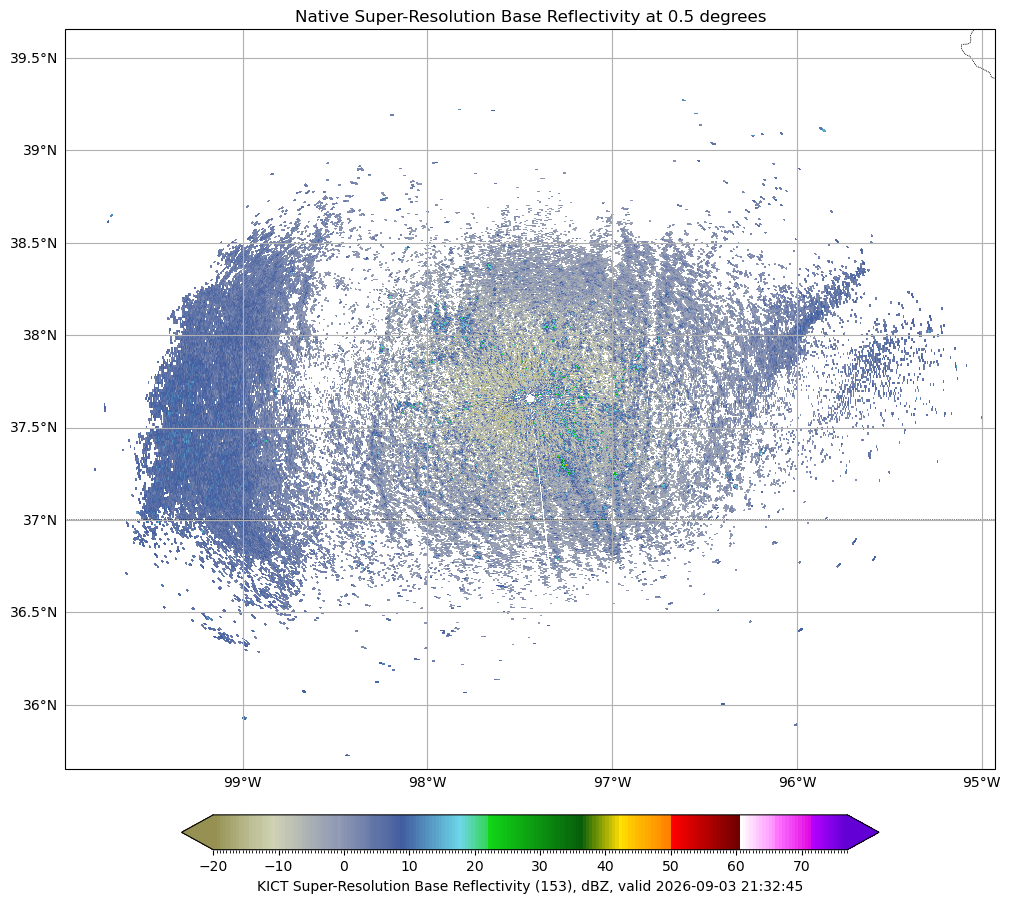

In [9]:
fig, ax = make_map(base_bbox)
mesh = ax.pcolormesh(
    base_lons, base_lats, base_data, shading="flat",
    transform=ccrs.PlateCarree(), **product_plot_style(product)
)
ax.set_aspect("equal", "datalim")
cbar = fig.colorbar(mesh, ax=ax, extend="both", shrink=0.75,
                    orientation="horizontal", pad=0.05)
unit = product.get("displayUnit", product.get("unit", ""))
cbar.set_label(
    f"{site.upper()} {product['name']} ({product_code}), {unit}, "
    f"valid {record.getDataTime()}"
)
ax.set_title(f"Native {product['name']} at {elevation:g} degrees")
ax.set_xlim(longitude - 2.0, longitude + 2.0)
ax.set_ylim(latitude - 2.0, latitude + 2.0)
plt.show()

## Summary

* `getAvailableParameters()` discovers every product available for a radar site.
* `tables.nexrad` maps numeric product codes to readable metadata.
* `getAvailableLevels()` discovers the actual elevation angles for the selected
  site, product, and volume coverage pattern.
* `getGridData()` supplies the standard gridded interface.
* `GetRadarDataRecordRequest` supplies native radial bins and metadata.